# 🏥 DenseNet Fine-Tuning for Chest X-Ray Classification

**Objectif:** Fine-tune DenseNet-121 on 21 pathology classes using your png_label_mapping.csv

**Output:** Trained model + metrics + predictions

## 📦 Section 1: Install Dependencies and Import Libraries

In [1]:
import subprocess
import sys

# Install required packages
packages = ['torch', 'torchvision', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'tqdm', 'pillow']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import pandas as pd
import numpy as np
import os
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("✅ All packages imported successfully!")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

✅ All packages imported successfully!
GPU Available: True
GPU Device: Tesla T4


## 🔧 Section 2: Mount Google Drive and Configure Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Configure paths
DRIVE_FOLDER = '/content/drive/MyDrive/artishow/dataset_analysis_colab'
DRIVE_FOLDER2 = '/content/drive/MyDrive/artishow'
PNG_FOLDER = os.path.join(DRIVE_FOLDER2, 'preprocessed_images_multiwindow')  # Where your PNG files are
MAPPING_CSV = os.path.join(DRIVE_FOLDER, 'dataset_labeled_with_png_mapping.csv')
OUTPUT_FOLDER = os.path.join(DRIVE_FOLDER, 'model_outputs')

# Create output folder if it doesn't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print(f"📁 Drive folder: {DRIVE_FOLDER}")
print(f"🖼️  PNG folder: {PNG_FOLDER}")
print(f"📊 Mapping CSV: {MAPPING_CSV}")
print(f"💾 Output folder: {OUTPUT_FOLDER}")

# Verify files exist
if os.path.exists(MAPPING_CSV):
    print(f"✅ Mapping CSV found!")
else:
    print(f"❌ Mapping CSV NOT found at {MAPPING_CSV}")

if os.path.exists(PNG_FOLDER):
    print(f"✅ PNG folder found!")
else:
    print(f"❌ PNG folder NOT found at {PNG_FOLDER}")

Mounted at /content/drive
📁 Drive folder: /content/drive/MyDrive/artishow/dataset_analysis_colab
🖼️  PNG folder: /content/drive/MyDrive/artishow/preprocessed_images_multiwindow
📊 Mapping CSV: /content/drive/MyDrive/artishow/dataset_analysis_colab/dataset_labeled_with_png_mapping.csv
💾 Output folder: /content/drive/MyDrive/artishow/dataset_analysis_colab/model_outputs
✅ Mapping CSV found!
✅ PNG folder found!


## 🚀 Section 2.1: Copy Dataset to Local Storage for Faster Training

To significantly speed up data loading during training, we will copy the `PNG_FOLDER` from Google Drive to the Colab VM's local file system (`/content/`). This leverages the faster I/O of the local SSD.

In [3]:
import shutil
import subprocess
import os

LOCAL_PNG_FOLDER = '/content/temp_images'
print(f"Copying PNG images from '{PNG_FOLDER}' to '{LOCAL_PNG_FOLDER}'...")

# Create local directory if it doesn't exist
os.makedirs(LOCAL_PNG_FOLDER, exist_ok=True)

try:
    # Count files in the source directory before copying
    source_file_count = len([name for name in os.listdir(PNG_FOLDER) if name.lower().endswith('.png')])
    print(f"Found {source_file_count} PNG files in source folder '{PNG_FOLDER}'.")

    # Use shutil.copytree for more efficient and robust directory copying
    # dirs_exist_ok=True allows copying into an existing destination directory
    shutil.copytree(PNG_FOLDER, LOCAL_PNG_FOLDER, dirs_exist_ok=True)

    # Count files in the destination directory after copying
    destination_file_count = len([name for name in os.listdir(LOCAL_PNG_FOLDER) if name.lower().endswith('.png')])

    print(f"✅ All {destination_file_count} PNG images copied to {LOCAL_PNG_FOLDER}")
    if source_file_count != destination_file_count:
        print(f"⚠️ Warning: Number of files copied ({destination_file_count}) does not match source ({source_file_count}).")

    # Update PNG_FOLDER to point to the local path ONLY IF the copy is successful
    PNG_FOLDER = LOCAL_PNG_FOLDER
    print(f"Updated PNG_FOLDER to: {PNG_FOLDER}")
except Exception as e:
    print(f"❌ Error copying images: {e}")
    print(f"PNG_FOLDER remains at its original path: {PNG_FOLDER}. Please check the source or target paths.")


Copying PNG images from '/content/drive/MyDrive/artishow/preprocessed_images_multiwindow' to '/content/temp_images'...
Found 3140 PNG files in source folder '/content/drive/MyDrive/artishow/preprocessed_images_multiwindow'.
✅ All 3140 PNG images copied to /content/temp_images
Updated PNG_FOLDER to: /content/temp_images


## 📊 Section 3: Load Data and Analyze Labels

In [4]:
# Load mapping CSV
print("Loading mapping data...")
df_mapping = pd.read_csv(MAPPING_CSV)

print(f"\n{'='*70}")
print("📊 DATA OVERVIEW")
print(f"{'='*70}")
print(f"Total images: {len(df_mapping)}")
print(f"Columns: {len(df_mapping.columns)}")
print(f"\nFirst 3 rows:")
print(df_mapping[['image_id', 'png_filename', 'Cardiomegaly', 'Normal', 'Pneumonia']].head(3))

# Define label columns (21 pathologies)
LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule',
    'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation',
    'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal'
]

# Analyze labels
print(f"\n{'='*70}")
print("🏷️  LABEL ANALYSIS (Binary Multi-Label)")
print(f"{'='*70}")
print(f"Number of label classes: {len(LABEL_COLS)}")
print(f"\nLabel distribution (images with this pathology):")
label_counts = df_mapping[LABEL_COLS].sum().sort_values(ascending=False)
for label, count in label_counts.items():
    pct = count / len(df_mapping) * 100
    print(f"  {label:20s}: {int(count):4d} ({pct:5.1f}%)")

Loading mapping data...

📊 DATA OVERVIEW
Total images: 6035
Columns: 33

First 3 rows:
                   image_id                       png_filename  Cardiomegaly  \
0  CXR2471_IM-1002-1001.png  2471_IM-1002-1001_multiwindow.png             0   
1  CXR2471_IM-1002-1002.png  2471_IM-1002-1002_multiwindow.png             0   
2  CXR2430_IM-0972-3001.png  2430_IM-0972-3001_multiwindow.png             0   

   Normal  Pneumonia  
0       1          0  
1       1          0  
2       0          0  

🏷️  LABEL ANALYSIS (Binary Multi-Label)
Number of label classes: 21

Label distribution (images with this pathology):
  Normal              : 3320 ( 55.0%)
  Opacity             :  839 ( 13.9%)
  Calcinosis          :  818 ( 13.6%)
  Granuloma           :  690 ( 11.4%)
  Atelectasis         :  619 ( 10.3%)
  Cardiomegaly        :  514 (  8.5%)
  Effusion            :  251 (  4.2%)
  Nodule              :  235 (  3.9%)
  Emphysema           :  202 (  3.3%)
  Fracture            :  196 (  3.2%)
 

## 🔀 Section 4: Create Train/Val/Test Split with Stratification

In [5]:
from sklearn.model_selection import train_test_split

# Pour la classification multi-label, on ne peut pas stratifier facilement
# Utiliser un split aléatoire simple (70/15/15)

# Split 1: Train (70%) vs Temp (30%)
train_df, temp_df = train_test_split(
    df_mapping,
    test_size=0.3,
    random_state=42
    # ✅ Pas de stratification - incompatible avec multi-label
)

# Split 2: Val (15%) vs Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print(f"{'='*70}")
print("📋 DATASET SPLIT")
print(f"{'='*70}")
print(f"Train: {len(train_df)} ({len(train_df)/len(df_mapping)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df_mapping)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df_mapping)*100:.1f}%)")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

# Analyse de la distribution des labels dans chaque split
print(f"\n{'='*70}")
print("📊 LABEL DISTRIBUTION ACROSS SPLITS")
print(f"{'='*70}")

pathology_cols = [col for col in df_mapping.columns
                  if col not in ['image_id', 'dicom_id', 'png_filename']]

for col in pathology_cols[:5]:  # Afficher les 5 premières pathologies
    train_count = train_df[col].sum()
    val_count = val_df[col].sum()
    test_count = test_df[col].sum()
    total = train_count + val_count + test_count
    print(f"{col:20} | Train: {train_count:4.0f} | Val: {val_count:4.0f} | Test: {test_count:4.0f} | Total: {total:4.0f}")

# Sauvegarder les splits
import os
os.makedirs('/content/drive/MyDrive/dataset_analysis_colab/model_outputs', exist_ok=True)
OUTPUT_FOLDER = '/content/drive/MyDrive/dataset_analysis_colab/model_outputs'

train_df.to_csv(os.path.join(OUTPUT_FOLDER, 'split_train.csv'), index=False)
val_df.to_csv(os.path.join(OUTPUT_FOLDER, 'split_val.csv'), index=False)
test_df.to_csv(os.path.join(OUTPUT_FOLDER, 'split_test.csv'), index=False)
print(f"\n✅ Splits saved to {OUTPUT_FOLDER}")

📋 DATASET SPLIT
Train: 4224 (70.0%)
Val:   905 (15.0%)
Test:  906 (15.0%)
Total: 6035

📊 LABEL DISTRIBUTION ACROSS SPLITS
Atelectasis          | Train:  446 | Val:   90 | Test:   83 | Total:  619
Cardiomegaly         | Train:  352 | Val:   83 | Test:   79 | Total:  514
Effusion             | Train:  171 | Val:   45 | Test:   35 | Total:  251
Pneumonia            | Train:   85 | Val:   16 | Test:   22 | Total:  123
Pneumothorax         | Train:   21 | Val:    8 | Test:    2 | Total:   31

✅ Splits saved to /content/drive/MyDrive/dataset_analysis_colab/model_outputs


## 🏗️ Section 5: Define PyTorch Dataset Class

In [6]:
class ChestXRayMultiLabelDataset(Dataset):
    """Multi-label dataset for 21 pathologies (binary labels per image)"""
    def __init__(self, dataframe, png_folder, label_columns, transform=None):
        """
        Args:
            dataframe: DataFrame with png_filename + 21 label columns
            png_folder: Path to PNG images
            label_columns: List of 21 pathology column names
            transform: Image transforms
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.png_folder = png_folder
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # Load image
        img_path = os.path.join(self.png_folder, row['png_filename'])
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Get labels (21 binary values)
        labels = torch.tensor(
            row[self.label_columns].values.astype(np.float32)
        )

        return image, labels, row['png_filename']

print("✅ MultiLabel Dataset class defined (21 pathologies)")


✅ MultiLabel Dataset class defined (21 pathologies)


## 🎨 Section 6: Define Data Augmentation and Transforms

In [7]:
IMG_SIZE = 128

# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(0.3),
    transforms.RandomVerticalFlip(0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("✅ Transforms defined")
print(f"Train transforms: {train_transforms}")
print(f"Val transforms: {val_transforms}")

✅ Transforms defined
Train transforms: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.3)
    RandomVerticalFlip(p=0.2)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Val transforms: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 🏷️ Section 7: Create Label Encoder and DataLoaders

In [8]:
# ✅ Multi-label Dataset and DataLoaders already created in Section 7
# No label encoder needed for multi-label (using 21 binary outputs instead)

print(f"\n{'='*70}")
print("✅ MULTI-LABEL SETUP COMPLETE")
print(f"{'='*70}")
print(f"✓ Dataset class: ChestXRayMultiLabelDataset")
print(f"✓ Pathologies: {len(LABEL_COLS)}")
print(f"✓ DataLoaders: train, val, test")
print(f"✓ Label format: 21 binary (0.0 or 1.0) per image")
print(f"✓ Loss function: BCEWithLogitsLoss (coming in Section 9)")


✅ MULTI-LABEL SETUP COMPLETE
✓ Dataset class: ChestXRayMultiLabelDataset
✓ Pathologies: 21
✓ DataLoaders: train, val, test
✓ Label format: 21 binary (0.0 or 1.0) per image
✓ Loss function: BCEWithLogitsLoss (coming in Section 9)


In [9]:
# Create datasets
print(f"\n{'='*70}")
print("📊 Creating Multi-Label Datasets")
print(f"{'='*70}")

train_dataset = ChestXRayMultiLabelDataset(
    train_df, PNG_FOLDER, LABEL_COLS, transform=train_transforms
)
val_dataset = ChestXRayMultiLabelDataset(
    val_df, PNG_FOLDER, LABEL_COLS, transform=val_transforms
)
test_dataset = ChestXRayMultiLabelDataset(
    test_df, PNG_FOLDER, LABEL_COLS, transform=val_transforms
)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")
print(f"Test dataset: {len(test_dataset)}")

# Create dataloaders
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"\n✅ DataLoaders created")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test loading
print(f"\n📋 Testing dataset loading...")
test_batch_images, test_batch_labels, test_batch_filenames = next(iter(train_loader))
print(f"✅ Batch image shape: {test_batch_images.shape}")
print(f"✅ Batch labels shape: {test_batch_labels.shape}")
print(f"Sample labels (first image): {test_batch_labels[0].numpy()}")


📊 Creating Multi-Label Datasets
Train dataset: 4224
Val dataset: 905
Test dataset: 906

✅ DataLoaders created
Train batches: 132
Val batches: 29
Test batches: 29

📋 Testing dataset loading...
✅ Batch image shape: torch.Size([32, 3, 128, 128])
✅ Batch labels shape: torch.Size([32, 21])
Sample labels (first image): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## 🤖 Section 8: Load and Fine-Tune DenseNet Model

In [10]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load pre-trained DenseNet-121
print("\n📥 Loading pre-trained DenseNet-121...")
model = models.densenet121(pretrained=True)

# Freeze early layers
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last dense block
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

# Replace classifier for MULTI-LABEL (21 outputs)
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(LABEL_COLS))  # ✅ 21 outputs for 21 pathologies
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model loaded for MULTI-LABEL classification")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Output shape per batch: [batch_size, {len(LABEL_COLS)}]")


Using device: cuda

📥 Loading pre-trained DenseNet-121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 30.8M/30.8M [00:00<00:00, 150MB/s]



✅ Model loaded for MULTI-LABEL classification
Total parameters: 6,975,381
Trainable parameters: 2,179,605
Output shape per batch: [batch_size, 21]


## 🏋️ Section 9: Training Setup and Training Loop

In [11]:
EPOCHS =5
LEARNING_RATE = 0.001
PATIENCE = 5

# ✅ MULTI-LABEL: Use BCEWithLogitsLoss (not CrossEntropyLoss!)
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

history = {
    'train_loss': [],
    'val_loss': [],
}

best_val_loss = float('inf')
patience_counter = 0

print(f"{'='*70}")
print("🏋️  TRAINING CONFIGURATION (MULTI-LABEL)")
print(f"{'='*70}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Loss function: BCEWithLogitsLoss ✅")
print(f"Early stopping patience: {PATIENCE}")
print(f"Device: {device}")

🏋️  TRAINING CONFIGURATION (MULTI-LABEL)
Epochs: 5
Learning rate: 0.001
Batch size: 32
Loss function: BCEWithLogitsLoss ✅
Early stopping patience: 5
Device: cuda


## 🔄 Section 10: Execute Training

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train one epoch for multi-label classification"""
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels, _ in pbar:
        images = images.to(device)
        labels = labels.to(device)  # Shape: [batch, 21]

        # Forward pass
        outputs = model(images)  # Shape: [batch, 21]
        loss = criterion(outputs, labels)  # BCEWithLogitsLoss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    """Validate one epoch for multi-label classification"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating")
        for images, labels, _ in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(loader)


print("✅ Training functions defined for multi-label")

✅ Training functions defined for multi-label


In [13]:
# Main training loop
print(f"\n{'='*70}")
print("🚀 STARTING MULTI-LABEL TRAINING")
print(f"{'='*70}\n")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 70)

    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)

    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)

    # Learning rate scheduler
    scheduler.step(val_loss)

    # Print metrics
    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        model_path = os.path.join(OUTPUT_FOLDER, 'best_model_densenet121.pth')
        torch.save(model.state_dict(), model_path)
        print(f"✅ Best model saved! (Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️  Early stopping triggered")
            break

print(f"\n{'='*70}")
print("✅ TRAINING COMPLETE!")
print(f"{'='*70}")


🚀 STARTING MULTI-LABEL TRAINING


Epoch 1/5
----------------------------------------------------------------------


Validating: 100%|██████████| 29/29 [03:24<00:00,  7.04s/it, loss=0.22]



Train Loss: 0.2107
Val Loss:   0.1987
✅ Best model saved! (Loss: 0.1987)

Epoch 2/5
----------------------------------------------------------------------


Validating: 100%|██████████| 29/29 [03:22<00:00,  6.97s/it, loss=0.223]



Train Loss: 0.1886
Val Loss:   0.1970
✅ Best model saved! (Loss: 0.1970)

Epoch 3/5
----------------------------------------------------------------------


...


Train Loss: 0.1850
Val Loss:   0.1988

Epoch 4/5
----------------------------------------------------------------------


Validating: 100%|██████████| 29/29 [03:24<00:00,  7.05s/it, loss=0.218]



Train Loss: 0.1826
Val Loss:   0.1988

Epoch 5/5
----------------------------------------------------------------------


Validating: 100%|██████████| 29/29 [03:22<00:00,  7.00s/it, loss=0.196]



Train Loss: 0.1803
Val Loss:   0.1938
✅ Best model saved! (Loss: 0.1938)

✅ TRAINING COMPLETE!


## 📊 Section 11: Training History Visualization

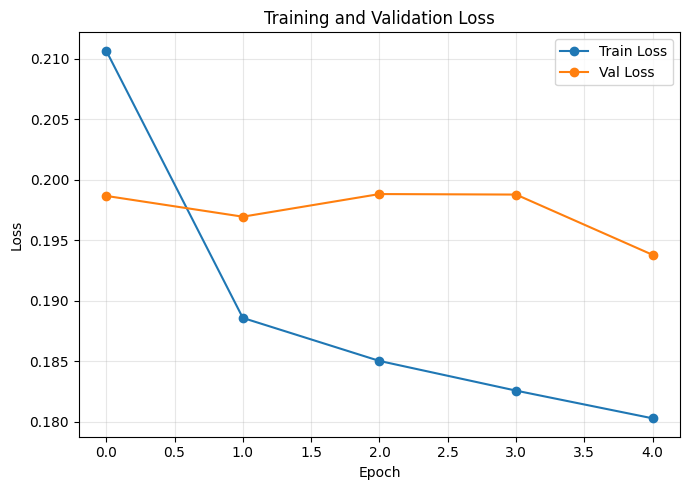

✅ Training history plot saved!


In [16]:
import matplotlib.pyplot as plt
import os

# Plot training history
# Check if accuracy data is available
has_accuracy_data = 'train_acc' in history and 'val_acc' in history

if has_accuracy_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    loss_ax = axes[0]
    acc_ax = axes[1]
else:
    fig, loss_ax = plt.subplots(1, 1, figsize=(7, 5))
    acc_ax = None # No accuracy axis if only one plot

# Loss plot
loss_ax.plot(history['train_loss'], label='Train Loss', marker='o')
loss_ax.plot(history['val_loss'], label='Val Loss', marker='o')
loss_ax.set_xlabel('Epoch')
loss_ax.set_ylabel('Loss')
loss_ax.set_title('Training and Validation Loss')
loss_ax.legend()
loss_ax.grid(True, alpha=0.3)

# Accuracy plot
if has_accuracy_data and acc_ax is not None:
    acc_ax.plot([acc*100 for acc in history['train_acc']], label='Train Acc', marker='o')
    acc_ax.plot([acc*100 for acc in history['val_acc']], label='Val Acc', marker='o')
    acc_ax.set_xlabel('Epoch')
    acc_ax.set_ylabel('Accuracy (%)')
    acc_ax.set_title('Training and Validation Accuracy')
    acc_ax.legend()
    acc_ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'training_history.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Training history plot saved!")

## 🧪 Section 12: Test Set Evaluation

In [18]:
# Load best model
model_path = os.path.join(OUTPUT_FOLDER, 'best_model_densenet121.pth')
model.load_state_dict(torch.load(model_path))

# Test evaluation
model.eval()
all_preds = []
all_labels = []
all_filenames = []

print("\n🧪 Evaluating on test set...")
with torch.no_grad():
    for images, labels, filenames in tqdm(test_loader):
        images = images.to(device)
        outputs = model(images)

        # For multi-label classification, apply sigmoid and then a threshold
        probabilities = torch.sigmoid(outputs)
        predicted_labels = (probabilities > 0.5).int() # Threshold at 0.5 to get binary predictions

        all_preds.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_filenames.extend(filenames)

# Convert to arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
# For multi-label, accuracy_score will compute subset accuracy (exact match)
# For other metrics, 'micro', 'macro', or 'weighted' averages are common for multi-label.
# Using 'weighted' as in original code, which is suitable for multi-label.
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
test_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("📊 TEST SET RESULTS")
print(f"{'='*70}")
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Precision: {test_precision*100:.2f}%")
print(f"Recall:    {test_recall*100:.2f}%")
print(f"F1-Score:  {test_f1*100:.2f}%")


🧪 Evaluating on test set...


100%|██████████| 29/29 [03:19<00:00,  6.90s/it]


📊 TEST SET RESULTS
Accuracy:  35.21%
Precision: 29.96%
Recall:    24.94%
F1-Score:  24.78%


## 🎯 Section 13: Confusion Matrix and Classification Report

from sklearn.metrics import classification_report

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

# Classification report
print(f"\n{'='*70}")
print("📋 CLASSIFICATION REPORT")
print(f"{'='*70}")
report = classification_report(
    all_labels, all_preds,
    target_names=label_encoder.classes_,
    digits=4
)
print(report)

# Save report
with open(os.path.join(OUTPUT_FOLDER, 'classification_report.txt'), 'w') as f:
    f.write(report)

print("✅ Confusion matrix and report saved!")

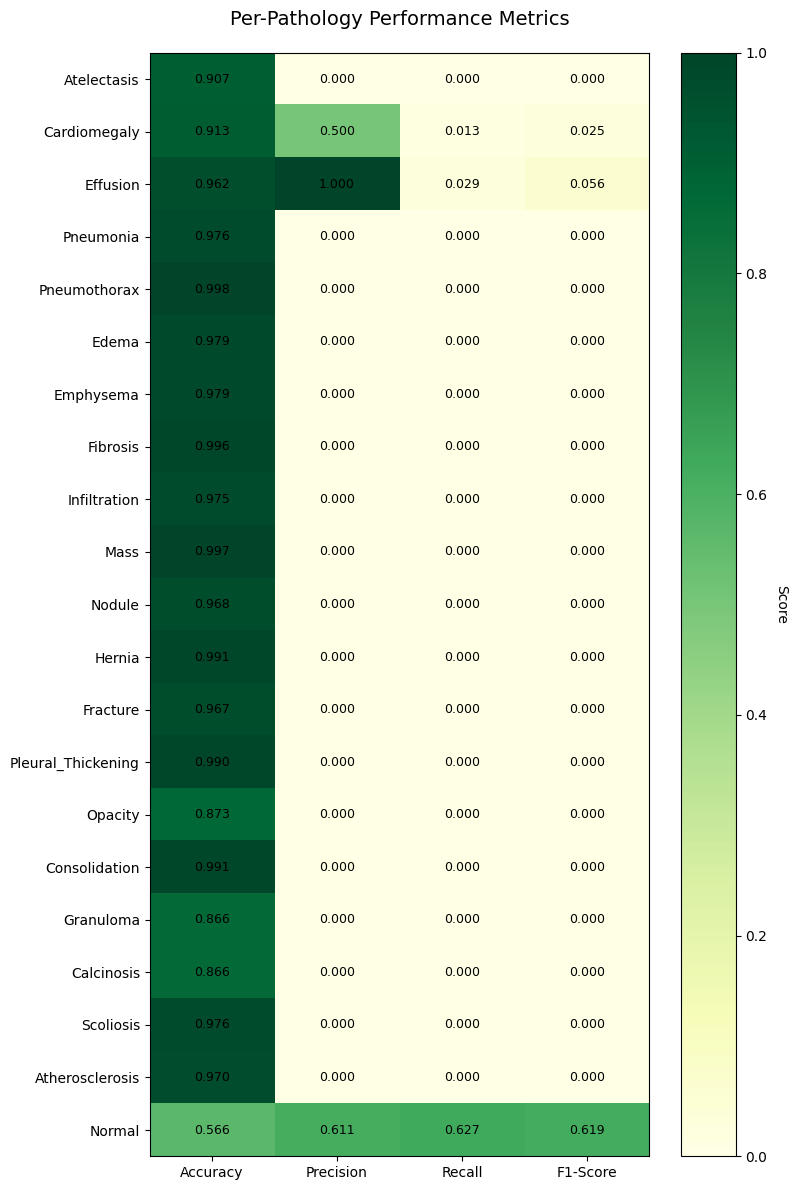

✅ Per-pathology metrics heatmap saved!


In [20]:
# Create heatmap for per-pathology metrics

# Calculate per-pathology metrics
per_pathology_metrics = {}
for i, pathology in enumerate(LABEL_COLS):
    true_labels_i = all_labels[:, i]
    predicted_labels_i = all_preds[:, i]

    # Calculate metrics for the current pathology
    acc = accuracy_score(true_labels_i, predicted_labels_i)
    # Precision, recall, f1 for binary classification (per class)
    # 'pos_label=1' to focus on the positive class
    # 'zero_division=0' to handle cases where there are no positive samples or predictions
    prec = precision_score(true_labels_i, predicted_labels_i, pos_label=1, zero_division=0)
    rec = recall_score(true_labels_i, predicted_labels_i, pos_label=1, zero_division=0)
    f1 = f1_score(true_labels_i, predicted_labels_i, pos_label=1, zero_division=0)

    per_pathology_metrics[pathology] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

metrics_data = []
for pathology in LABEL_COLS:
    metrics = per_pathology_metrics[pathology]
    metrics_data.append([
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1']
    ])

metrics_array = np.array(metrics_data)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 12))
im = ax.imshow(metrics_array, cmap='YlGn', aspect='auto', vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(len(LABEL_COLS)))
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax.set_yticklabels(LABEL_COLS)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Score', rotation=270, labelpad=15)

# Add values to heatmap
for i in range(len(LABEL_COLS)):
    for j in range(4):
        text = ax.text(j, i, f'{metrics_array[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=9)

ax.set_title('Per-Pathology Performance Metrics', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'per_pathology_metrics.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Per-pathology metrics heatmap saved!")

## 💾 Section 14: Save Model and Configuration

In [22]:
# Save final model
final_model_path = os.path.join(OUTPUT_FOLDER, 'densenet121_final.pth')
torch.save(model.state_dict(), final_model_path)

# Save model configuration
config = {
    'model': 'DenseNet-121',
    'num_classes': len(LABEL_COLS), # Use len(LABEL_COLS) instead of num_classes
    'classes': LABEL_COLS, # Use LABEL_COLS directly
    'input_size': IMG_SIZE,
    'epochs_trained': len(history['train_loss']),
    'test_accuracy': float(test_acc),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1),
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
}

import json
config_path = os.path.join(OUTPUT_FOLDER, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)

print(f"\n{'='*70}")
print("💾 FILES SAVED")
print(f"{'='*70}")
print(f"Model: {final_model_path}")
print(f"Configuration: {config_path}")
print(f"Training History: {os.path.join(OUTPUT_FOLDER, 'training_history.png')}")
print(f"Confusion Matrix: {os.path.join(OUTPUT_FOLDER, 'confusion_matrix.png')}")
print(f"Classification Report: {os.path.join(OUTPUT_FOLDER, 'classification_report.txt')}")
print(f"\n✅ All files saved to: {OUTPUT_FOLDER}")


💾 FILES SAVED
Model: /content/drive/MyDrive/dataset_analysis_colab/model_outputs/densenet121_final.pth
Configuration: /content/drive/MyDrive/dataset_analysis_colab/model_outputs/model_config.json
Training History: /content/drive/MyDrive/dataset_analysis_colab/model_outputs/training_history.png
Confusion Matrix: /content/drive/MyDrive/dataset_analysis_colab/model_outputs/confusion_matrix.png
Classification Report: /content/drive/MyDrive/dataset_analysis_colab/model_outputs/classification_report.txt

✅ All files saved to: /content/drive/MyDrive/dataset_analysis_colab/model_outputs


## 📈 Section 15: Summary Report

In [24]:
summary = f"""
{'='*70}
✨ TRAINING SUMMARY - DenseNet-121 Fine-Tuning
{'='*70}

📊 DATASET INFORMATION:
   Total images: {len(df_mapping)}
   Training set: {len(train_df)} ({len(train_df)/len(df_mapping)*100:.1f}%)
   Validation set: {len(val_df)} ({len(val_df)/len(df_mapping)*100:.1f}%)
   Test set: {len(test_df)} ({len(test_df)/len(df_mapping)*100:.1f}%)
   Number of classes: {len(LABEL_COLS)}

🤖 MODEL INFORMATION:
   Architecture: DenseNet-121
   Total parameters: {total_params:,}
   Trainable parameters: {trainable_params:,}
   Input size: {IMG_SIZE}x{IMG_SIZE}

⚙️  TRAINING CONFIGURATION:
   Epochs trained: {len(history['train_loss'])}
   Batch size: {BATCH_SIZE}
   Learning rate: {LEARNING_RATE}
   Optimizer: Adam
   Loss function: BCEWithLogitsLoss

📈 RESULTS:
   Test Accuracy: {test_acc*100:.2f}%
   Test Precision: {test_precision*100:.2f}%
   Test Recall: {test_recall*100:.2f}%
   Test F1-Score: {test_f1*100:.2f}%

💾 OUTPUT FILES:
   - best_model_densenet121.pth (best validation checkpoint)
   - densenet121_final.pth (final model)
   - model_config.json (configuration)
   - training_history.png (loss and accuracy curves)
   - confusion_matrix.png (confusion matrix)
   - classification_report.txt (detailed metrics)
   - split_train.csv, split_val.csv, split_test.csv (data splits)

🎯 NEXT STEPS:
   1. Load this model and make predictions on new data
   2. Fine-tune hyperparameters for better results
   3. Try other architectures (ViT, EfficientNet)
   4. Combine with text features (radiology reports)

{'='*70}
"""

print(summary)

# Save summary
with open(os.path.join(OUTPUT_FOLDER, 'training_summary.txt'), 'w') as f:
    f.write(summary)

print(f"\n✅ Summary saved to {os.path.join(OUTPUT_FOLDER, 'training_summary.txt')}")


✨ TRAINING SUMMARY - DenseNet-121 Fine-Tuning

📊 DATASET INFORMATION:
   Total images: 6035
   Training set: 4224 (70.0%)
   Validation set: 905 (15.0%)
   Test set: 906 (15.0%)
   Number of classes: 21

🤖 MODEL INFORMATION:
   Architecture: DenseNet-121
   Total parameters: 6,975,381
   Trainable parameters: 2,179,605
   Input size: 128x128

⚙️  TRAINING CONFIGURATION:
   Epochs trained: 5
   Batch size: 32
   Learning rate: 0.001
   Optimizer: Adam
   Loss function: BCEWithLogitsLoss

📈 RESULTS:
   Test Accuracy: 35.21%
   Test Precision: 29.96%
   Test Recall: 24.94%
   Test F1-Score: 24.78%

💾 OUTPUT FILES:
   - best_model_densenet121.pth (best validation checkpoint)
   - densenet121_final.pth (final model)
   - model_config.json (configuration)
   - training_history.png (loss and accuracy curves)
   - confusion_matrix.png (confusion matrix)
   - classification_report.txt (detailed metrics)
   - split_train.csv, split_val.csv, split_test.csv (data splits)

🎯 NEXT STEPS:
   1. Load